In [10]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Download Data
tickers = [
    'JPM','GS','MS',          # Finance
    'AAPL','MSFT','NVDA','AMZN', # Technology
    'XOM','CVX','COP','SLB'   # Energy
]

data = yf.download(tickers, start="2000-01-01", auto_adjust=False)
print(data.head())
adj_close = data['Adj Close']
adj_close.columns.name = None

# 3. Daily Returns
daily_returns = adj_close.pct_change().dropna()

# 4. Annualized Returns & Covariance
mean_daily = daily_returns.mean()
mean_annual = mean_daily * 252
cov_daily = daily_returns.cov()
cov_annual = cov_daily * 252

print("Annualized Mean Returns:\n",mean_annual)



[*********************100%***********************]  11 of 11 completed

Price      Adj Close                                                       \
Ticker          AAPL  AMZN   COP    CVX     GS    JPM     MS   MSFT  NVDA   
Date                                                                        
2000-01-03     0.840 4.469 7.635 16.053 61.664 23.126 33.064 35.668 0.089   
2000-01-04     0.769 4.097 7.488 16.053 57.780 22.618 30.615 34.463 0.087   
2000-01-05     0.781 3.487 7.351 16.341 55.074 22.479 29.497 34.827 0.084   
2000-01-06     0.713 3.278 7.603 17.036 57.431 22.798 30.063 33.660 0.079   
2000-01-07     0.747 3.478 7.603 17.336 57.649 23.217 30.997 34.100 0.080   

Price              ...     Volume                                       \
Ticker        SLB  ...       AMZN      COP      CVX       GS       JPM   
Date               ...                                                   
2000-01-03 16.873  ...  322352000  1862219  4387600  1822600  12019200   
2000-01-04 16.642  ...  349748000  1472879  3702400  1647700  11723400   
2000-01-05 16

In [2]:
# 5. Portfolio Simulation
n_assets = len(tickers)
n_portfolios = 20000
rf_rate = 0.05  # risk-free rate

results = np.zeros((3, n_portfolios))  # return, vol, sharpe
weights_record = []

for i in range(n_portfolios):
    # Random weights
    weights = np.random.random(n_assets)
    weights /= np.sum(weights)
    weights_record.append(weights)

    # Expected portfolio return
    port_return = np.dot(weights, mean_annual)

    # Portfolio volatility
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_annual, weights)))

    # Sharpe Ratio
    sharpe = (port_return - rf_rate) / port_vol

    results[0,i] = port_return
    results[1,i] = port_vol
    results[2,i] = sharpe


In [3]:
# 6. Find Optimal Portfolios
max_sharpe_idx = np.argmax(results[2])
min_vol_idx = np.argmin(results[1])

max_sharpe_ret, max_sharpe_vol = results[0,max_sharpe_idx], results[1,max_sharpe_idx]
min_vol_ret, min_vol_vol = results[0,min_vol_idx], results[1,min_vol_idx]

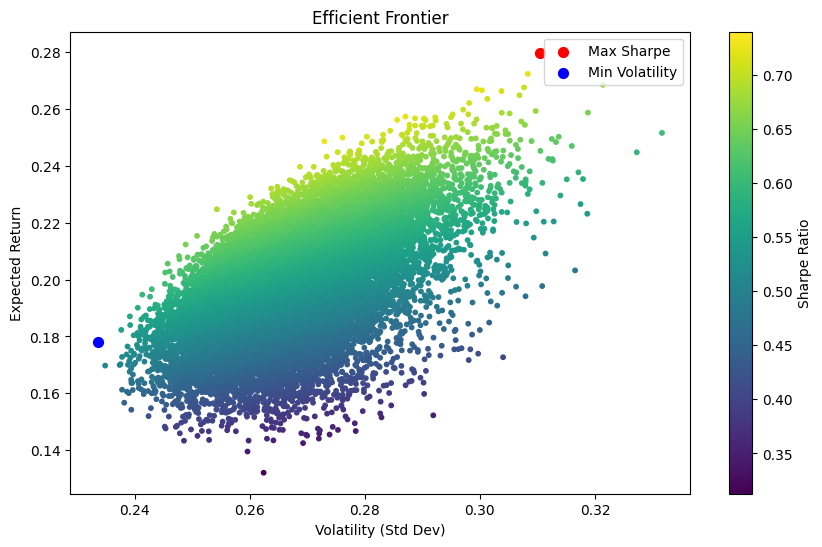

In [4]:
# 7. Plot Efficient Frontier
plt.figure(figsize=(10,6))
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', s=10)
plt.colorbar(label='Sharpe Ratio')

# Mark max Sharpe
plt.scatter(max_sharpe_vol, max_sharpe_ret, c='red', s=50, label='Max Sharpe')

# Mark min volatility
plt.scatter(min_vol_vol, min_vol_ret, c='blue', s=50, label='Min Volatility')

plt.xlabel('Volatility (Std Dev)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier')
plt.legend()
plt.show()

In [5]:
# 8. Display Optimal Weights
opt_sharpe_weights = pd.Series(weights_record[max_sharpe_idx], index=tickers)
opt_minvol_weights = pd.Series(weights_record[min_vol_idx], index=tickers)


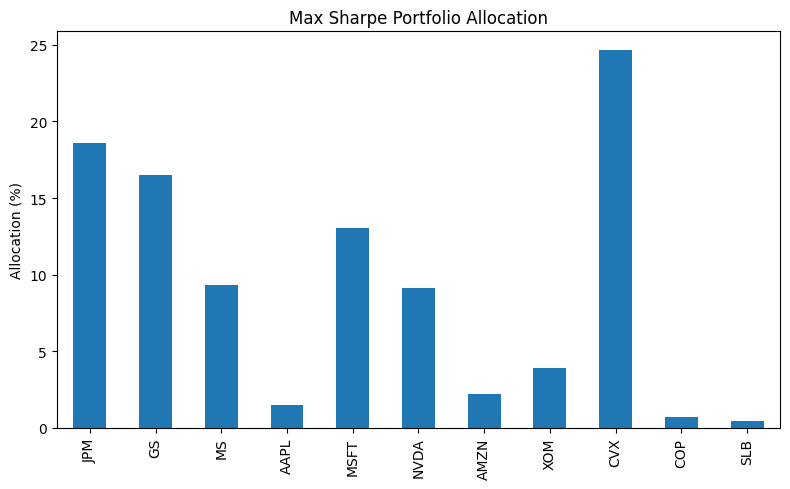

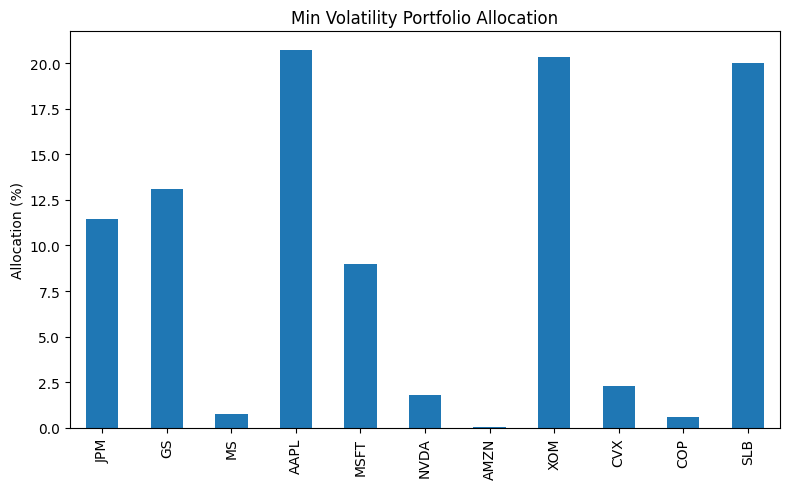

In [6]:
# 9. Bar chart of allocations

def plot_allocations(weights, title):
    plt.figure(figsize=(8,5))
    (weights*100).plot(kind='bar')
    plt.ylabel('Allocation (%)')
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Max Sharpe allocation
plot_allocations(opt_sharpe_weights, "Max Sharpe Portfolio Allocation")

# Min Volatility allocation
plot_allocations(opt_minvol_weights, "Min Volatility Portfolio Allocation")

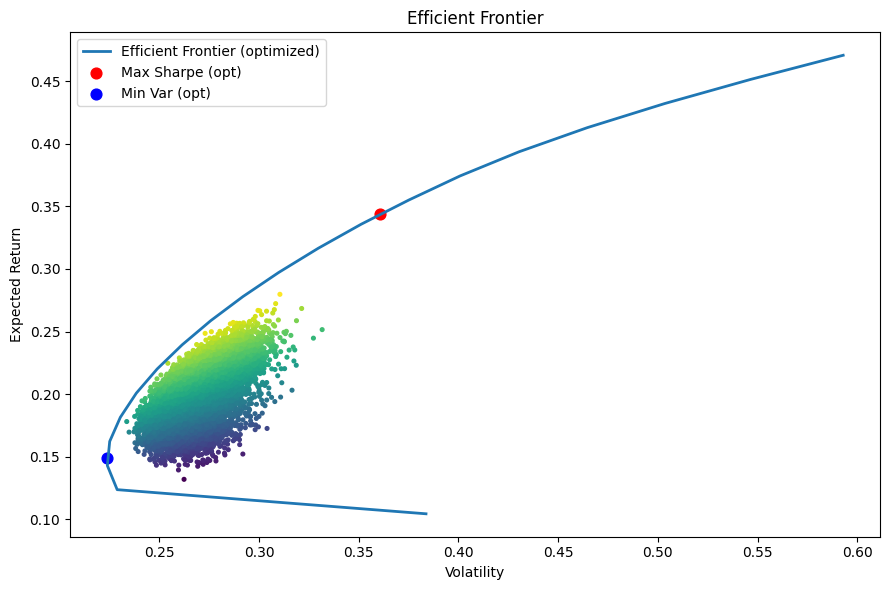

In [12]:
# PHASE 4 — MODEL BUILDING

# Imports for optimization
from scipy.optimize import minimize


# Helpers
def ann_metrics(weights, mu=mean_annual, cov=cov_annual, rf=rf_rate):
    w = np.array(weights)
    pret = float(w @ mu)
    pvol = float(np.sqrt(w @ cov @ w))
    psh = (pret - rf) / pvol if pvol > 0 else -np.inf
    return pret, pvol, psh

def max_drawdown(series):
    roll_max = np.maximum.accumulate(series)
    dd = series/roll_max - 1.0
    return float(dd.min())

def eval_from_daily(w, rets_daily, rf_annual=rf_rate):
    # convert rf to daily
    rf_daily = (1 + rf_annual)**(1/252) - 1
    port_daily = (rets_daily @ w)
    cum = (1 + port_daily).cumprod()
    ann_ret = (1 + port_daily.mean())**252 - 1
    ann_vol = port_daily.std() * np.sqrt(252)
    sharpe = (ann_ret - rf_annual) / ann_vol if ann_vol > 0 else np.nan
    mdd = max_drawdown(cum)
    return {"ann_return": ann_ret, "ann_vol": ann_vol, "sharpe": sharpe, "max_drawdown": mdd}

# Heuristics
# A) Top-k by individual Sharpe (daily)
asset_sharpes = (mean_daily*252 - rf_rate) / (daily_returns.std()*np.sqrt(252))
k = 5
topk = asset_sharpes.sort_values(ascending=False).head(k).index.tolist()
w_topk_eq = pd.Series(0.0, index=tickers)
w_topk_eq[topk] = 1/len(topk)

# B) Low-correlation greedy subset (threshold)
corr = daily_returns.corr()
thr = 0.75
chosen = []
for t in tickers:
    if all(abs(corr.loc[t, c]) <= thr for c in chosen):
        chosen.append(t)
w_lowcorr_eq = pd.Series(0.0, index=tickers)
w_lowcorr_eq[chosen] = 1/len(chosen)

# Traditional baselines
w_equal = pd.Series(1/len(tickers), index=tickers)

# Mean–Variance optimization (continuous, long-only)
bounds = [(0,1)]*n_assets
cons_sum1 = {"type":"eq", "fun": lambda w: np.sum(w) - 1}

def solve_min_var(target_ret=None):
    if target_ret is None:
        # pure min variance
        def obj(w): return w @ cov_annual @ w
        res = minimize(obj, np.repeat(1/n_assets, n_assets), bounds=bounds, constraints=[cons_sum1])
        return pd.Series(res.x, index=tickers)
    else:
        cons_ret = {"type":"eq", "fun": lambda w: w @ mean_annual - target_ret}
        def obj(w): return w @ cov_annual @ w
        res = minimize(obj, np.repeat(1/n_assets, n_assets),
                       bounds=bounds, constraints=[cons_sum1, cons_ret])
        return pd.Series(res.x, index=tickers)

# Sweep efficient frontier points
targets = np.linspace(mean_annual.min(), mean_annual.max(), 20)
ef_weights = [solve_min_var(tr) for tr in targets]
ef_metrics = [ann_metrics(w.values) for w in ef_weights]

# Max Sharpe optimization (continuous, long-only)
def solve_max_sharpe():
    def neg_sharpe(w):
        r, v, s = ann_metrics(w)
        return -s
    res = minimize(neg_sharpe, np.repeat(1/n_assets, n_assets),
                   bounds=bounds, constraints=[cons_sum1],
                   options={"maxiter": 500})
    return pd.Series(res.x, index=tickers)
w_maxsh = solve_max_sharpe()
w_minvar = solve_min_var()

# Constrained optimization (realistic caps)
# per-asset <= 30%; sector caps: Tech <= 50%, Finance <= 40%, Energy <= 40%
sector = {
    "JPM":"Finance","GS":"Finance","MS":"Finance",
    "AAPL":"Tech","MSFT":"Tech","NVDA":"Tech","AMZN":"Tech",
    "XOM":"Energy","CVX":"Energy","COP":"Energy","SLB":"Energy"
}
asset_cap = 0.30
bounds_cap = [(0, asset_cap)]*n_assets

def sector_cons(limit, label):
    mask = np.array([1 if sector[t]==label else 0 for t in tickers], dtype=float)
    return {"type":"ineq", "fun": lambda w, m=mask, L=limit: L - np.dot(m,w)}

cons_caps = [
    cons_sum1,
    sector_cons(0.50, "Tech"),
    sector_cons(0.40, "Finance"),
    sector_cons(0.40, "Energy"),
]

def solve_max_sharpe_constrained():
    def neg_sharpe(w):
        r, v, s = ann_metrics(w)
        return -s
    res = minimize(neg_sharpe, np.repeat(1/n_assets, n_assets),
                   bounds=bounds_cap, constraints=cons_caps,
                   options={"maxiter": 1000})
    return pd.Series(res.x, index=tickers)

w_maxsh_c = solve_max_sharpe_constrained()

# Efficient frontier points from optimization
plt.figure(figsize=(9,6))
plt.scatter(results[1,:], results[0,:], c=results[2,:], s=7)  # your MC cloud
ef_vol = [np.sqrt(w.values @ cov_annual.values @ w.values) for w in ef_weights]
ef_ret = [w.values @ mean_annual.values for w in ef_weights]
plt.plot(ef_vol, ef_ret, linewidth=2, label="Efficient Frontier (optimized)")

# markers
r,v,_ = ann_metrics(w_maxsh.values)
plt.scatter(v, r, c='red', s=60, label='Max Sharpe (opt)')
r,v,_ = ann_metrics(w_minvar.values)
plt.scatter(v, r, c='blue', s=60, label='Min Var (opt)')
plt.xlabel('Volatility'); plt.ylabel('Expected Return'); plt.title('Efficient Frontier')
plt.legend(); plt.tight_layout(); plt.show()




=== Phase 5: Out-of-sample evaluation (start: 2022-01-01) ===
                      Portfolio  Train Ret  Train Vol  Train Sharpe  \
5      Max Sharpe (constrained)      0.347      0.319         0.933   
6            Your MC Max Sharpe      0.320      0.316         0.855   
3              Max Sharpe (opt)      0.415      0.366         0.996   
0                         Equal      0.213      0.269         0.608   
4                 Min Var (opt)      0.152      0.228         0.447   
7               Your MC Min Vol      0.192      0.238         0.597   
2      Heuristic: Low-Corr (eq)      0.197      0.268         0.547   
1  Heuristic: Top-5 Sharpe (eq)      0.200      0.303         0.496   

   Train MDD  Test Ret  Test Vol  Test Sharpe  Test MDD  
5     -0.614     0.345     0.281        1.051    -0.329  
6     -0.657     0.340     0.277        1.045    -0.307  
3     -0.685     0.380     0.326        1.011    -0.371  
0     -0.574     0.255     0.223        0.919    -0.221  
4     -

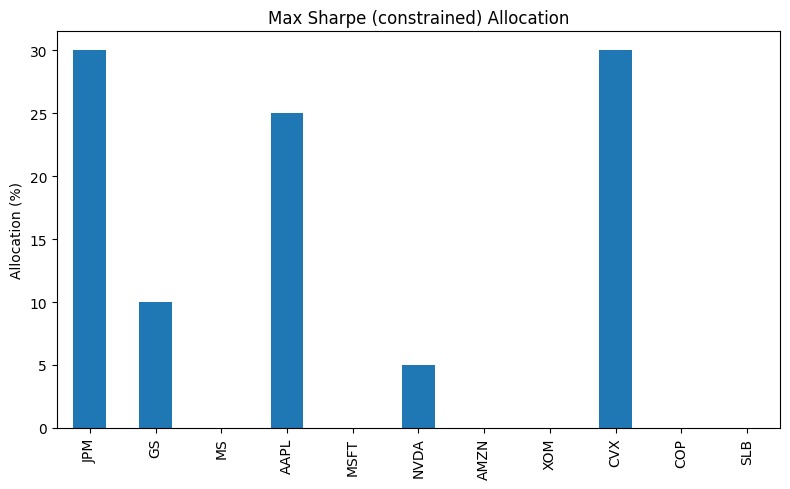

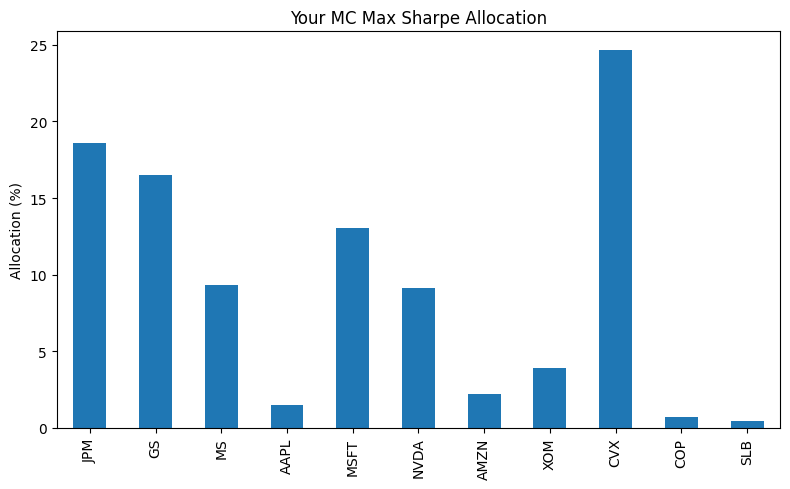

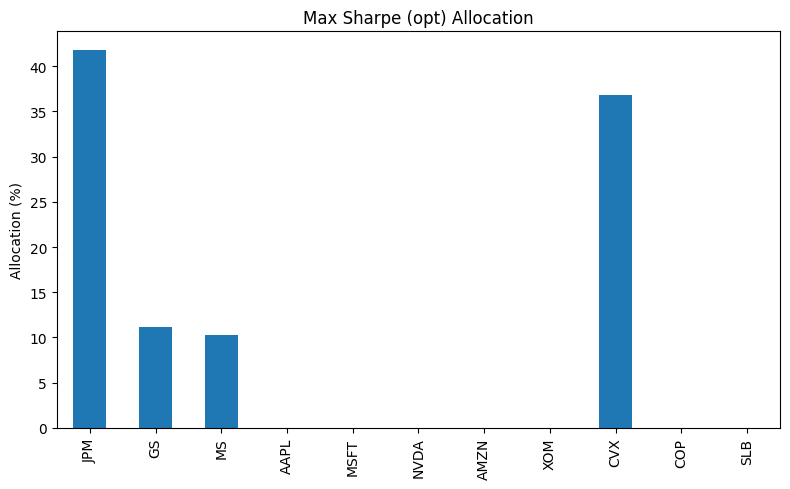


Sector exposure of top model:
sector
Finance    40.0%
Energy     30.0%
Tech       30.0%
Name: weight, dtype: object


In [11]:
# PHASE 5 — MODEL EVALUATION

# Split train/test
test_start = "2022-01-01"
train_rets = daily_returns.loc[:pd.to_datetime(test_start)-pd.Timedelta(days=1)]
test_rets  = daily_returns.loc[pd.to_datetime(test_start):]

candidate_weights = {
    "Equal": w_equal,
    "Heuristic: Top-5 Sharpe (eq)": w_topk_eq,
    "Heuristic: Low-Corr (eq)": w_lowcorr_eq,
    "Max Sharpe (opt)": w_maxsh,
    "Min Var (opt)": w_minvar,
    "Max Sharpe (constrained)": w_maxsh_c,
    "Your MC Max Sharpe": opt_sharpe_weights,   # from random simulation
    "Your MC Min Vol": opt_minvol_weights       # from random simulation
}

def clean_w(w):
    # Align and normalize to 1
    w = w.reindex(tickers).fillna(0.0)
    s = w.sum()
    return (w/s) if s>0 else w

# Evaluate
rows = []
for name, w in candidate_weights.items():
    wv = clean_w(w).values
    trn = eval_from_daily(wv, train_rets)
    tst = eval_from_daily(wv, test_rets)
    rows.append({
        "Portfolio": name,
        "Train Ret": trn["ann_return"],
        "Train Vol": trn["ann_vol"],
        "Train Sharpe": trn["sharpe"],
        "Train MDD": trn["max_drawdown"],
        "Test Ret": tst["ann_return"],
        "Test Vol": tst["ann_vol"],
        "Test Sharpe": tst["sharpe"],
        "Test MDD": tst["max_drawdown"],
    })

summary = pd.DataFrame(rows).sort_values("Test Sharpe", ascending=False)
pd.set_option('display.float_format', lambda x: f"{x:,.3f}")
print("\n=== Phase 5: Out-of-sample evaluation (start: {}) ===".format(test_start))
print(summary)

# plot allocations for key winners
winners = summary.head(3)["Portfolio"].tolist()
for name in winners:
    plot_allocations(clean_w(candidate_weights[name]), f"{name} Allocation")

# show sector exposures for the top model
def sector_exposure(w):
    df = pd.DataFrame({"ticker": tickers, "weight": clean_w(w).values})
    df["sector"] = df["ticker"].map(sector)
    return df.groupby("sector")["weight"].sum().sort_values(ascending=False)

print("\nSector exposure of top model:")
print(sector_exposure(candidate_weights[summary.iloc[0]['Portfolio']]).apply(lambda x: f"{x*100:.1f}%"))
